#### 0_weekly_salary_average

***Note:*** this is an Summary Projekt out of 3_Datasience

In [2]:
"""Getting everything set up"""
# Imports (always)
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

#Getting the Dataset
dataset_1 = load_dataset('lukebarousse/data_jobs')
# Transforming the Data into an Pandas df
df_1 = dataset_1['train'].to_pandas()


In [ ]:
#Note: In only need basic info to complete this task
df_1.info()

Text(0, 0.5, 'average salary')

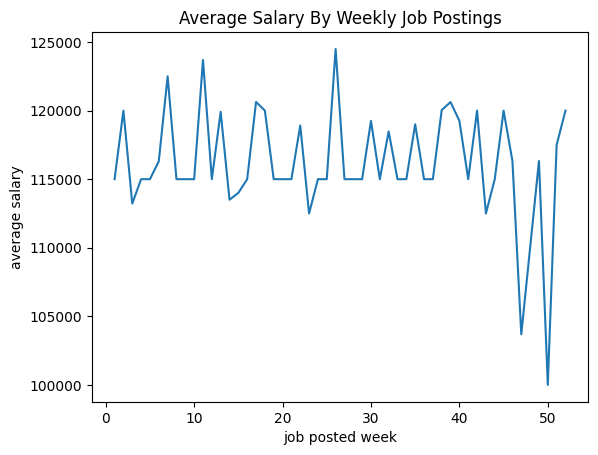

In [4]:
# Cleaning the Data 
df_1['job_posted_date'] = pd.to_datetime(df_1.job_posted_date)
df_1 = df_1.dropna(subset=['salary_year_avg'],how='all')

# Prepare the Data; I want to use the job_posted_week, so i need to create it !
df_1['job_posted_week'] = df_1.job_posted_date.dt.isocalendar().week

# Grouping the Data
weekly_salary_avg = df_1.groupby('job_posted_week')['salary_year_avg'].median().sort_index() 
""" Note: why sorting by index ?, sorting by index sorts by week, sorting by values sorts by high-low !"""

#Plotting the gathered data
plt.title("Average Salary By Weekly Job Postings")
plt.plot(weekly_salary_avg.index, weekly_salary_avg.values)
plt.xlabel("job posted week") # Index
plt.ylabel("average salary") # values